<div style="
  text-align:center;
  font-family:'Times New Roman', serif;
  margin-top:40px;
  padding:30px;
  background:rgba(221,160,221,0.35);  /* light transparent plum */
  color:#000;
  border-radius:12px;
  width:70%;
  margin-left:auto;
  margin-right:auto;
  backdrop-filter: blur(2px);
">

  <h2 style="margin-top:0; margin-bottom:10px; font-weight:normal; text-align: center;">
    KNTU <br> Faculty of Mathematics and Computer Science
  </h2>

  <h1 style="margin-bottom:5px; text-align: center;">
    Implementating time series model from scratch
  </h1>

  <hr style="width:50%; border:0; border-top:1px solid #777; margin-bottom:25px;">

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Name:</strong> Koorosh Asil Gharehbaghi
  </p>

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Student ID:</strong> 40124463
  </p>

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Instructor:</strong> Dr. Malek Zadeh
  </p>

</div>


<h3 style = "color:firebrick"> importing numpy and matplotlib </h3>
<p style = "color:navy"><i> for fast and smooth execution and convenient implementation we use numpy. </i></p> 

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter


<h3 style = "color:firebrick"> MA(q) </h3>
<p style = "color:navy"><i> implementing MA(q) with given theta values </i></p> 

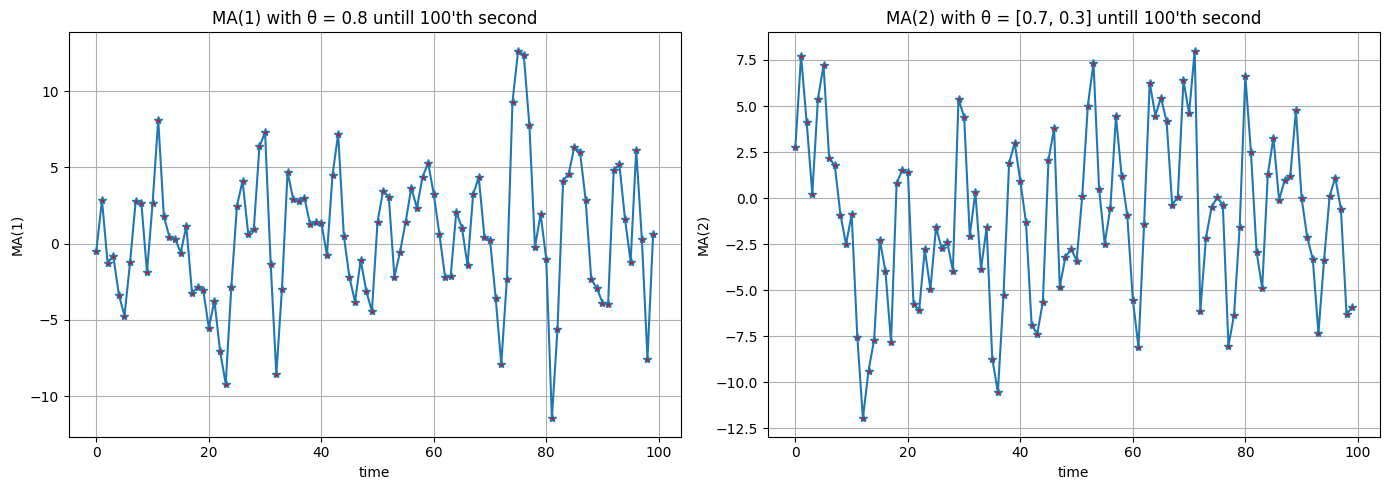

In [32]:


def MA(q, theta, n=100, seed=42, mean = 0, var= 1):
    np.random.seed(seed)
    Z = np.random.normal(mean, var, n + q)
    kernel = np.concatenate(([1], theta))   # shape: (q+1,)
    # in MA we have first thetha to be 1
    X = np.convolve(Z, kernel, mode='valid')

    return X

serie1 = MA(1, [0.8], var=3, n = 100, seed=21)
serie2 = MA(2, [0.7, 0.3], var=4, n = 100, seed=42)
time = np.arange(len(serie1))


fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(time, serie1, marker = '*', markerfacecolor = 'r', markersize = 6)
axs[0].set_xlabel("time")
axs[0].set_ylabel("MA(1)")
axs[0].set_title("MA(1) with θ = 0.8 untill 100'th second")
axs[0].grid()

axs[1].plot(time, serie2, marker = '*', markerfacecolor = 'r', markersize = 6)
axs[1].set_xlabel("time")
axs[1].set_ylabel("MA(2)")
axs[1].set_title("MA(2) with θ = [0.7, 0.3] untill 100'th second")
axs[1].grid()

plt.tight_layout()
plt.show()


<h3 style = "color:firebrick"> AR(p) </h3>
<p style = "color:navy"><i> implementing AR(p) with given phi values </i></p> 

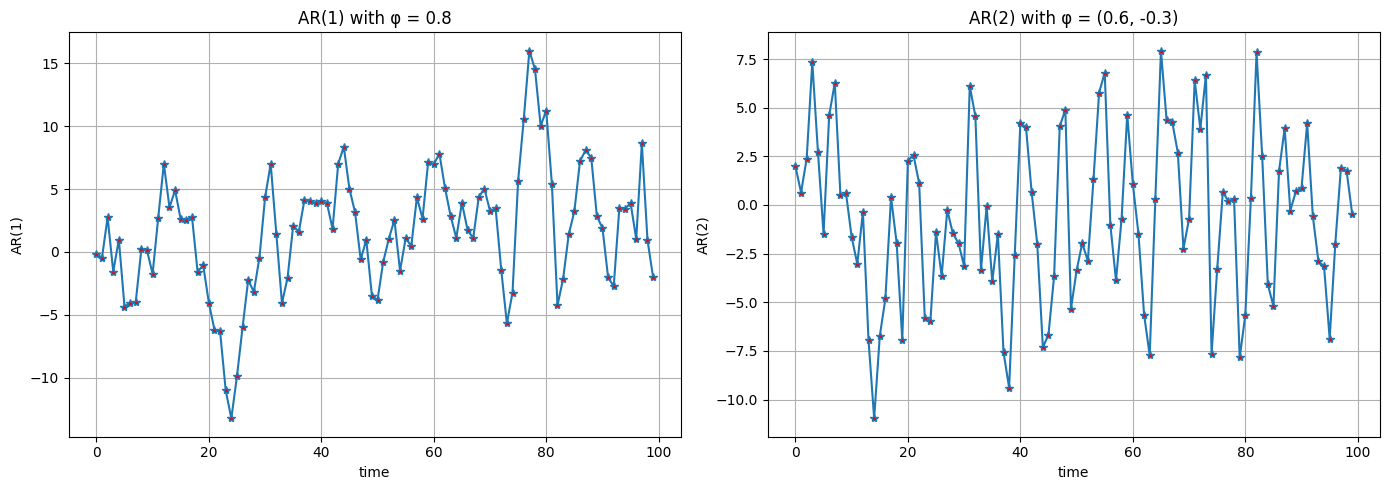

In [33]:

def AR(phi, n=100, seed=42, mean=0, var=1):
    np.random.seed(seed)
    eps = np.random.normal(mean, var, n)
    a = np.concatenate(([1], -np.array(phi)))
    b = [1]
    x = lfilter(b, a, eps)
    return x

serie_ar1 = AR([0.8], n=100, seed=21, var=3)
serie_ar2 = AR([0.6, -0.3], n=100, seed=42, var=4)

time = np.arange(len(serie_ar1))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(time, serie_ar1, marker='*', markerfacecolor='r', markersize=6)
axs[0].set_title("AR(1) with φ = 0.8")
axs[0].set_xlabel("time")
axs[0].set_ylabel("AR(1)")
axs[0].grid()

axs[1].plot(time, serie_ar2, marker='*', markerfacecolor='r', markersize=6)
axs[1].set_title("AR(2) with φ = (0.6, -0.3)")
axs[1].set_xlabel("time")
axs[1].set_ylabel("AR(2)")
axs[1].grid()

plt.tight_layout()
plt.show()


<h3 style = "color:firebrick"> ARMA(p,q) </h3>
<p style = "color:navy"><i> implementing ARMA(p,q) with given (phi,theta) values </i></p> 

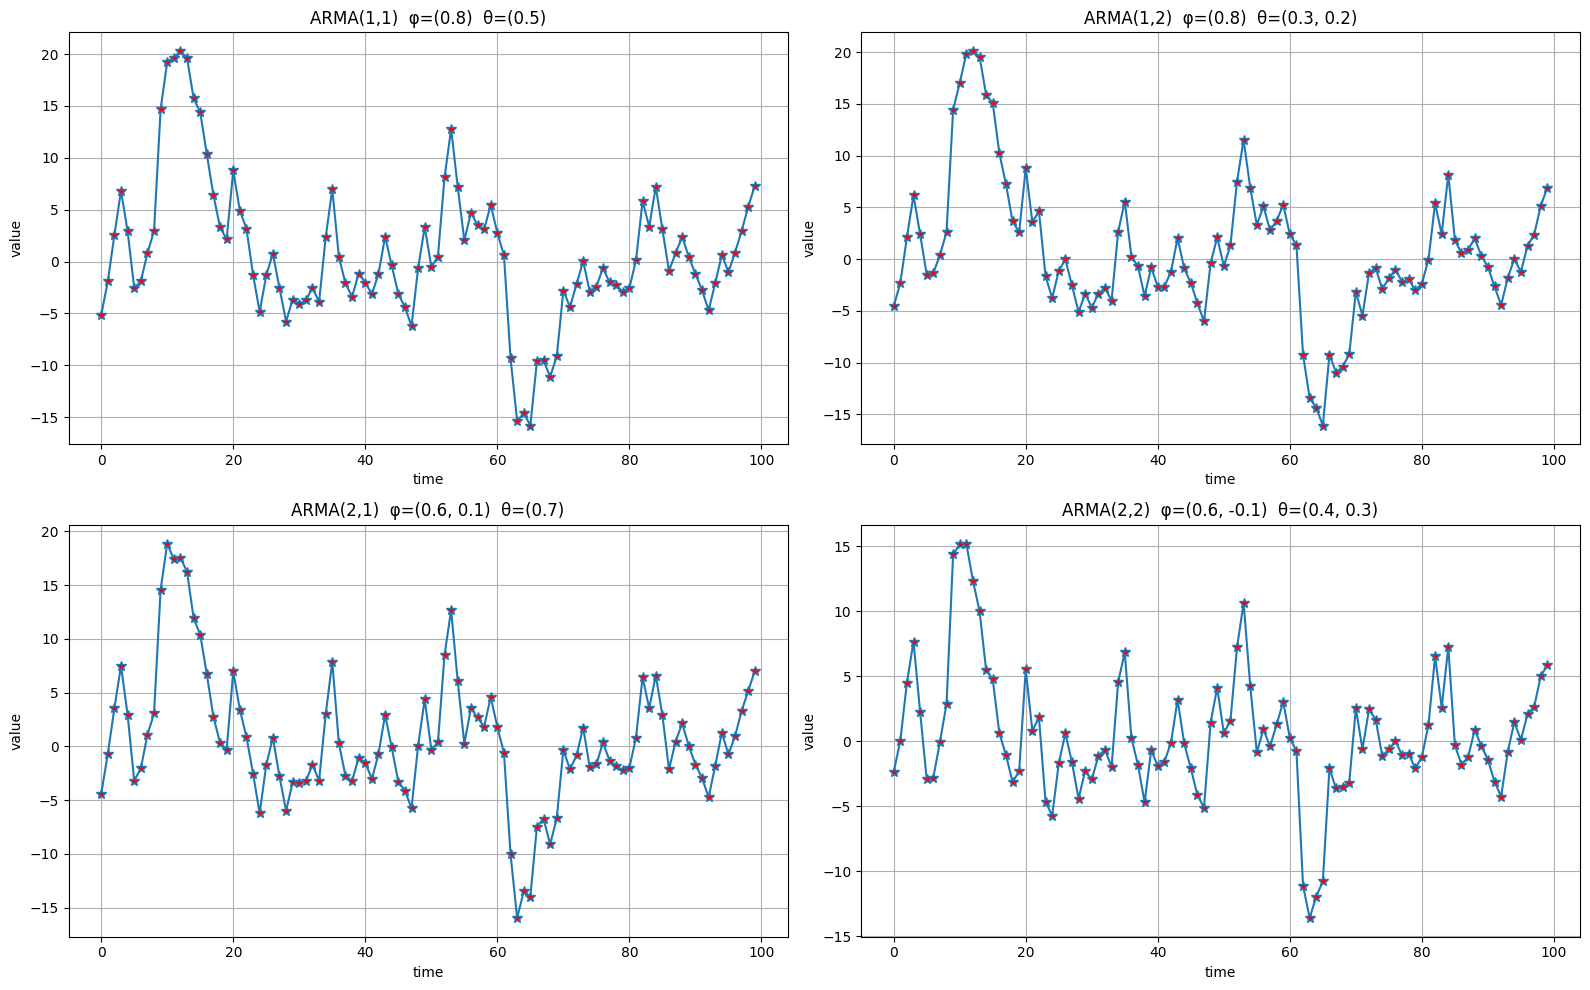

In [34]:
def ARMA(phi, theta, n=100, seed=21, mean=0, var=1, burn=200):
    np.random.seed(seed)
    eps = np.random.normal(mean, var, n + burn)
    a = np.concatenate(([1.0], -np.array(phi, dtype=float)))
    b = np.concatenate(([1.0], np.array(theta, dtype=float)))
    x = lfilter(b, a, eps)
    return x[burn:]

n = 100
serie_11 = ARMA([0.8], [0.5], n=n, seed=42, var=3)
serie_12 = ARMA([0.8], [0.3, 0.2], n=n, seed=42, var=3)
serie_21 = ARMA([0.6, 0.1], [0.7], n=n, seed=42, var=3)
serie_22 = ARMA([0.6, -0.1], [0.4, 0.3], n=n, seed=42, var=3)

time = np.arange(n)

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0, 0].plot(time, serie_11, marker='*', markerfacecolor='r', markersize=7)
axs[0, 0].set_title("ARMA(1,1)  φ=(0.8)  θ=(0.5)")
axs[0, 0].set_xlabel("time")
axs[0, 0].set_ylabel("value")
axs[0, 0].grid()

axs[0, 1].plot(time, serie_12, marker='*', markerfacecolor='r', markersize=7)
axs[0, 1].set_title("ARMA(1,2)  φ=(0.8)  θ=(0.3, 0.2)")
axs[0, 1].set_xlabel("time")
axs[0, 1].set_ylabel("value")
axs[0, 1].grid()

axs[1, 0].plot(time, serie_21, marker='*', markerfacecolor='r', markersize=7)
axs[1, 0].set_title("ARMA(2,1)  φ=(0.6, 0.1)  θ=(0.7)")
axs[1, 0].set_xlabel("time")
axs[1, 0].set_ylabel("value")
axs[1, 0].grid()

axs[1, 1].plot(time, serie_22, marker='*', markerfacecolor='r', markersize=7)
axs[1, 1].set_title("ARMA(2,2)  φ=(0.6, -0.1)  θ=(0.4, 0.3)")
axs[1, 1].set_xlabel("time")
axs[1, 1].set_ylabel("value")
axs[1, 1].grid()

plt.tight_layout()
plt.show()
